In [5]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
import random
import importlib
import helpers
importlib.reload(helpers)
from helpers import make_splits_by_is_test_or_date, smape, RHForecastDataset, CNNLSTMWithFuture, setup_matplotlib, COLORS

def _time_axis(ax):
    loc = AutoDateLocator()
    fmt = ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    ax.grid(True, which="major")
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)


def train_lstm_model(df, input_cols, target_col='RH_target', window_size=6, batch_size=64, use_scaler=True, epochs=20, hidden_size=128, num_layers=3, lr=0.001, save_dir=None, device: str = "cuda" if torch.cuda.is_available() else "cpu", df_index=None):
    scaler = None
    df_proc = df.copy()
    
    save_path = os.path.join(save_dir, f"df_{df_index}")
    save_path_scaler = os.path.join(save_dir, "scalers", f"df_{df_index}")
    os.makedirs(save_path, exist_ok=True)        
    os.makedirs(save_path_scaler, exist_ok=True)        

    scaler = StandardScaler()
    scaling_cols = [col for col in input_cols if not (col.startswith('hour_') or col.startswith('RH') or col.startswith('month'))]
    print(f"Scaling columns: {scaling_cols}")

    df_scaled = df_proc.copy()
    if target_col in df_scaled.columns:
        input_cols = [col for col in input_cols if col != target_col]
    df_scaled[scaling_cols] = scaler.fit_transform(df_scaled[scaling_cols])

    train_idx, val_idx, test_idx = make_splits_by_is_test_or_date(df_scaled)
    df_train = df_scaled.iloc[train_idx]
    df_val   = df_scaled.iloc[val_idx]
    df_test  = df_scaled.iloc[test_idx]

    ds_train = RHForecastDataset(df_train, input_cols, target_col, window_size)
    ds_val   = RHForecastDataset(df_val, input_cols, target_col, window_size)
    ds_test   = RHForecastDataset(df_test, input_cols, target_col, window_size)

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_val   = DataLoader(ds_val, batch_size=batch_size, shuffle=False)
    dl_test   = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

    model = CNNLSTMWithFuture(input_size=len(input_cols), hidden_size=hidden_size, num_layers=num_layers,
                                  cnn_out_channels=32, kernel_size=3).to(device)
    ckpt_name = f"best_rh.pt"   

    ckpt_path = os.path.join(save_path, ckpt_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_val_loss = float('inf') 

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb_seq, yb in dl_train:
            xb_seq, yb = xb_seq.to(device), yb.to(device)
            pred = model(xb_seq).squeeze()
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb_seq, yb in dl_val:
                xb_seq, yb = xb_seq.to(device), yb.to(device)
                if random.random() < 0.1:
                    xb_seq_clone = xb_seq.clone()
                    preds_seq = model(xb_seq_clone).detach()
                    xb_seq_clone[:, -1, 0] = preds_seq 
                    pred = model(xb_seq_clone).squeeze()
                else:
                    pred = model(xb_seq).squeeze()
                # pred = model(xb_seq).squeeze()
                loss = loss_fn(pred, yb)
                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        print(f"[{epoch+1:02d}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
        # if avg_loss < best_train_loss:
        #     best_train_loss = avg_loss
        #     torch.save(model.state_dict(), ckpt_path)
        #     print(f"✅ Saved best model at epoch {epoch+1} → {ckpt_path}")

    if ckpt_path:
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
        torch.save(best_model_state, ckpt_path)
        print(f"✅ Saved best RH model to {ckpt_path}")

    if df_index is not None:
        # scaler_path = f"models/scalers/df_{df_index}"
        scaler_save = os.path.join(save_path_scaler, "scaler_rh.pkl")
        joblib.dump(scaler, scaler_save)
        print(f"✅ Saved RH scaler to {scaler_save}")

    model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
    
    model.eval()

    test_timestamps = [df_proc.iloc[i].name for i in test_idx]

    preds, trues, times = [], [], []

    with torch.no_grad():
        batch_start = 0
        for xb_seq, yb in dl_test:
            xb_seq, yb = xb_seq.to(device), yb.to(device)
            out = model(xb_seq)
            preds.extend(out.cpu().numpy())
            trues.extend(yb.cpu().numpy())

            batch_size = len(xb_seq)
            times.extend(test_timestamps[batch_start:batch_start + batch_size])
            batch_start += batch_size

    rmse = root_mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    r2 = r2_score(trues, preds)
    smp = smape(trues, preds)
    
    metrics_df = pd.DataFrame(
        {
            "Metric": ["RMSE", "MAE", "R²", "sMAPE (%)"],
            "Value":  [rmse,  mae,   r2,   smp]
        }
    )
    metrics_df["Value"] = metrics_df["Value"].map(lambda v: f"{v:,.4f}")
    print("\n" + "="*47)
    print(" Performance Metrics".center(47, " "))
    print("="*47)
    print(metrics_df.to_string(index=False))
    print("="*47 + "\n")

    target_true = f"{target_col}_true"
    target_pred = f"{target_col}_pred" 
    results = pd.DataFrame(
        {target_true: trues, target_pred: preds},
        index=pd.to_datetime(times)
    ).sort_index()

    plt.rcParams.update({
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.28,
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "font.size": 11,
    })
    
    ylabel = "RH (%)"

    N_skip = 6
    N_plot = 96
    seg = results.iloc[N_skip:N_skip + N_plot]

    fig, ax = plt.subplots(figsize=(13.5, 4.8))
    ax.plot(seg.index, seg[target_true], lw=2.6, label="True", color="#1f77b4")
    # saturated solid orange—no choppy dashes
    ax.plot(seg.index, seg[target_pred], lw=2.6, label="Predicted", color="#FF7F0E", alpha=0.90)

    ax.set_title(
        f"Test Segment — {N_plot} points (skip {N_skip})\n"
        f"RMSE={rmse:.3f} • MAE={mae:.3f} • R²={r2:.3f} • sMAPE={smp:.2f}%",
        pad=12
    )
    ax.set_ylabel(ylabel)
    _time_axis(ax)
    leg = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    for ln in leg.get_lines(): ln.set_linewidth(3)
    fig.tight_layout(); plt.show()

    return model, scaler



In [7]:
def run_rh_cnnlstm_for_folder(
    folder_path: str,
    hvac_col: str = "hvac_mode",
    save_root: str = "models"
):
    
    # folder_path = 'datasets/retrofit/resampled'

    dfs = []

    for filename in os.listdir(folder_path):
        if filename.endswith('with_comfort.csv'):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
        
            df['timestamp'] = pd.to_datetime(df['timestamps'])
            
            df.drop(columns=['timestamps'], inplace=True)
            df.set_index('timestamp', inplace=True)
            df.sort_index(inplace=True)
            dfs.append(df)

    for index,df in enumerate(dfs):
        print(f"======= House {index} =========")

        rh_input_cols = [
            'RH', 'RH_lag1', 'RH_lag2', 'RH_lag3',
            'Tout', hvac_col, 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
        ]

        df = df.dropna(subset=["RH_target"])
        df = df.dropna(subset=rh_input_cols)

        # save_dir = os.path.join(save_root, f"df_{index}")
        os.makedirs(os.path.join(save_root, "scalers", f"df_{index}"), exist_ok=True)
        # os.makedirs(save_scaler_dir, exist_ok=True)
        # scaler_path = os.path.join(save_scaler_dir, 'scaler_rh.pk1')

        model_rh, scaler_rh = train_lstm_model(
            df,
            input_cols=rh_input_cols,
            target_col='RH_target', window_size=24, batch_size=128, use_scaler=True, epochs=50, hidden_size=128, num_layers=2, lr=0.001, save_dir=save_root, df_index=index
        )


======= House 0 =========
Scaling columns: ['Tout', 'hvac_mode']
[01] Train Loss: 615.3603 | Val Loss: 86.9835
[02] Train Loss: 163.0376 | Val Loss: 32.2038
[03] Train Loss: 88.6361 | Val Loss: 56.8558
[04] Train Loss: 77.5071 | Val Loss: 48.1714
[05] Train Loss: 40.5617 | Val Loss: 3.9188
[06] Train Loss: 19.5897 | Val Loss: 2.8711
[07] Train Loss: 12.1374 | Val Loss: 2.2283
[08] Train Loss: 8.3893 | Val Loss: 1.8982
[09] Train Loss: 6.3093 | Val Loss: 1.8987
[10] Train Loss: 4.8328 | Val Loss: 1.7175
[11] Train Loss: 3.9024 | Val Loss: 1.5924
[12] Train Loss: 3.3968 | Val Loss: 2.9633
[13] Train Loss: 2.8901 | Val Loss: 1.8143
[14] Train Loss: 2.5906 | Val Loss: 1.5500
[15] Train Loss: 2.3231 | Val Loss: 1.6625
[16] Train Loss: 2.0220 | Val Loss: 1.5827
[17] Train Loss: 1.9891 | Val Loss: 1.5741
[18] Train Loss: 1.9115 | Val Loss: 1.4422
[19] Train Loss: 1.7449 | Val Loss: 2.0534
[20] Train Loss: 1.7025 | Val Loss: 1.6903
[21] Train Loss: 1.6212 | Val Loss: 1.4754
[22] Train Loss: 1.

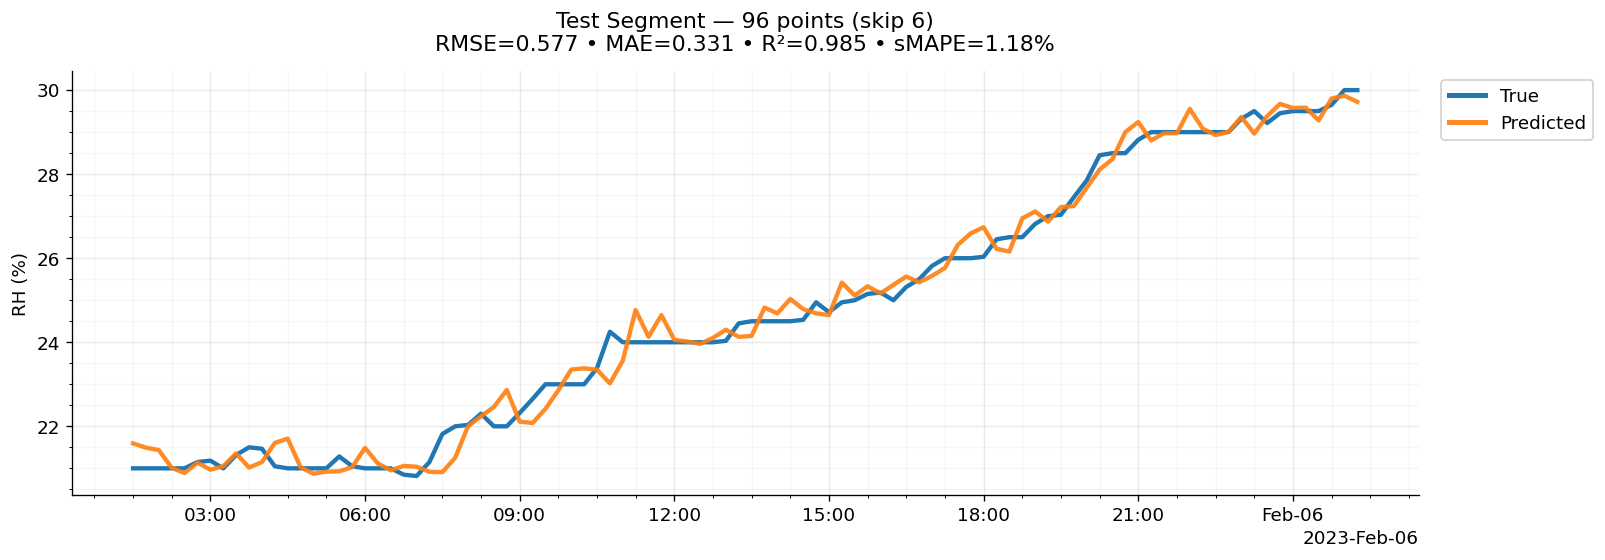

======= House 1 =========
Scaling columns: ['Tout', 'hvac_mode']
[01] Train Loss: 415.9290 | Val Loss: 28.0542
[02] Train Loss: 127.5623 | Val Loss: 61.2336
[03] Train Loss: 87.9865 | Val Loss: 4.1083
[04] Train Loss: 37.7892 | Val Loss: 2.8466
[05] Train Loss: 20.8917 | Val Loss: 2.2750
[06] Train Loss: 13.5797 | Val Loss: 2.0596
[07] Train Loss: 9.4019 | Val Loss: 1.8802
[08] Train Loss: 7.1722 | Val Loss: 2.1137
[09] Train Loss: 5.3690 | Val Loss: 1.7314
[10] Train Loss: 4.2751 | Val Loss: 1.6285
[11] Train Loss: 3.4351 | Val Loss: 1.6270
[12] Train Loss: 2.8556 | Val Loss: 1.5246
[13] Train Loss: 2.4466 | Val Loss: 1.6818
[14] Train Loss: 2.0659 | Val Loss: 1.7381
[15] Train Loss: 1.8586 | Val Loss: 1.4205
[16] Train Loss: 1.6495 | Val Loss: 1.3362
[17] Train Loss: 1.5177 | Val Loss: 1.3528
[18] Train Loss: 1.5138 | Val Loss: 1.3151
[19] Train Loss: 1.3199 | Val Loss: 1.9179
[20] Train Loss: 1.1771 | Val Loss: 1.4559
[21] Train Loss: 1.1651 | Val Loss: 1.2931
[22] Train Loss: 1.136

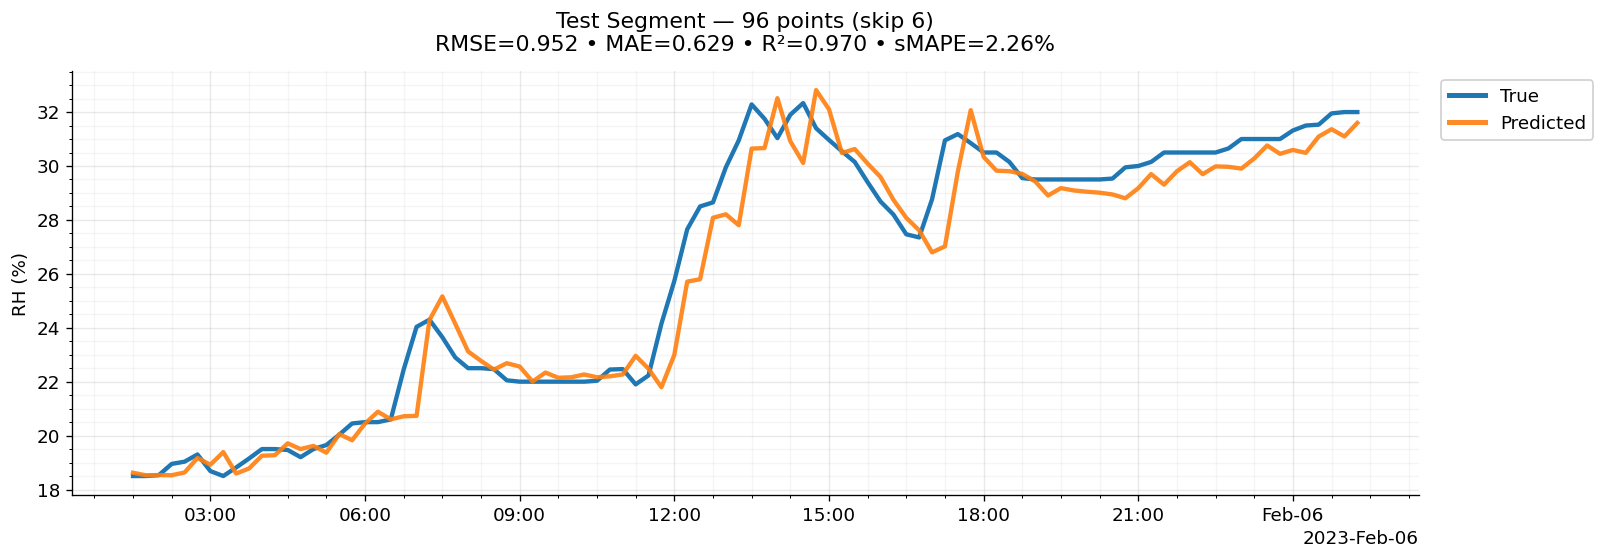

======= House 2 =========
Scaling columns: ['Tout', 'hvac_mode']
[01] Train Loss: 794.2346 | Val Loss: 142.8182
[02] Train Loss: 228.1132 | Val Loss: 29.5731
[03] Train Loss: 106.3984 | Val Loss: 48.8475
[04] Train Loss: 89.0966 | Val Loss: 65.7393
[05] Train Loss: 87.6375 | Val Loss: 70.7845
[06] Train Loss: 87.6416 | Val Loss: 71.1859
[07] Train Loss: 78.4885 | Val Loss: 4.9271
[08] Train Loss: 27.4304 | Val Loss: 2.0855
[09] Train Loss: 13.7782 | Val Loss: 1.8010
[10] Train Loss: 8.2766 | Val Loss: 1.7179
[11] Train Loss: 5.7517 | Val Loss: 2.2333
[12] Train Loss: 4.3108 | Val Loss: 1.4780
[13] Train Loss: 3.3798 | Val Loss: 1.5344
[14] Train Loss: 2.7922 | Val Loss: 1.4723
[15] Train Loss: 2.4173 | Val Loss: 1.4057
[16] Train Loss: 2.1895 | Val Loss: 1.3558
[17] Train Loss: 1.9422 | Val Loss: 1.4617
[18] Train Loss: 1.8371 | Val Loss: 1.3742
[19] Train Loss: 1.6252 | Val Loss: 1.2777
[20] Train Loss: 1.4504 | Val Loss: 1.2997
[21] Train Loss: 1.3668 | Val Loss: 1.4833
[22] Train Lo

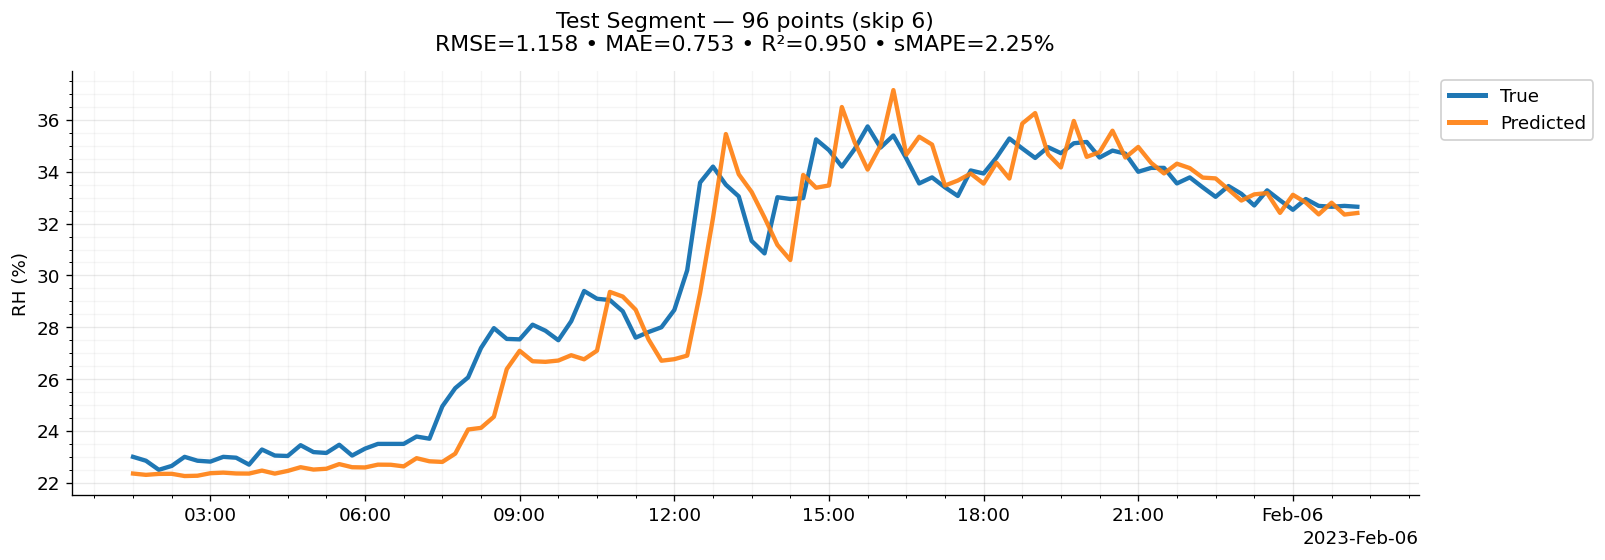

======= House 3 =========
Scaling columns: ['Tout', 'hvac_mode']
[01] Train Loss: 400.0373 | Val Loss: 26.2039
[02] Train Loss: 114.3652 | Val Loss: 47.8827
[03] Train Loss: 57.3523 | Val Loss: 1.1051
[04] Train Loss: 25.4569 | Val Loss: 0.8080
[05] Train Loss: 14.5637 | Val Loss: 1.3086
[06] Train Loss: 9.3879 | Val Loss: 0.8282
[07] Train Loss: 6.4522 | Val Loss: 0.5650
[08] Train Loss: 4.5844 | Val Loss: 0.5769
[09] Train Loss: 3.3874 | Val Loss: 0.6143
[10] Train Loss: 2.5670 | Val Loss: 0.5221
[11] Train Loss: 2.1397 | Val Loss: 0.4914
[12] Train Loss: 1.7427 | Val Loss: 0.5268
[13] Train Loss: 1.5203 | Val Loss: 0.5459
[14] Train Loss: 1.3019 | Val Loss: 0.6393
[15] Train Loss: 1.1933 | Val Loss: 0.5454
[16] Train Loss: 1.0075 | Val Loss: 0.5378
[17] Train Loss: 0.9490 | Val Loss: 0.5546
[18] Train Loss: 0.8563 | Val Loss: 0.3746
[19] Train Loss: 0.7790 | Val Loss: 0.4289
[20] Train Loss: 0.7582 | Val Loss: 0.4192
[21] Train Loss: 0.6837 | Val Loss: 0.4396
[22] Train Loss: 0.6669

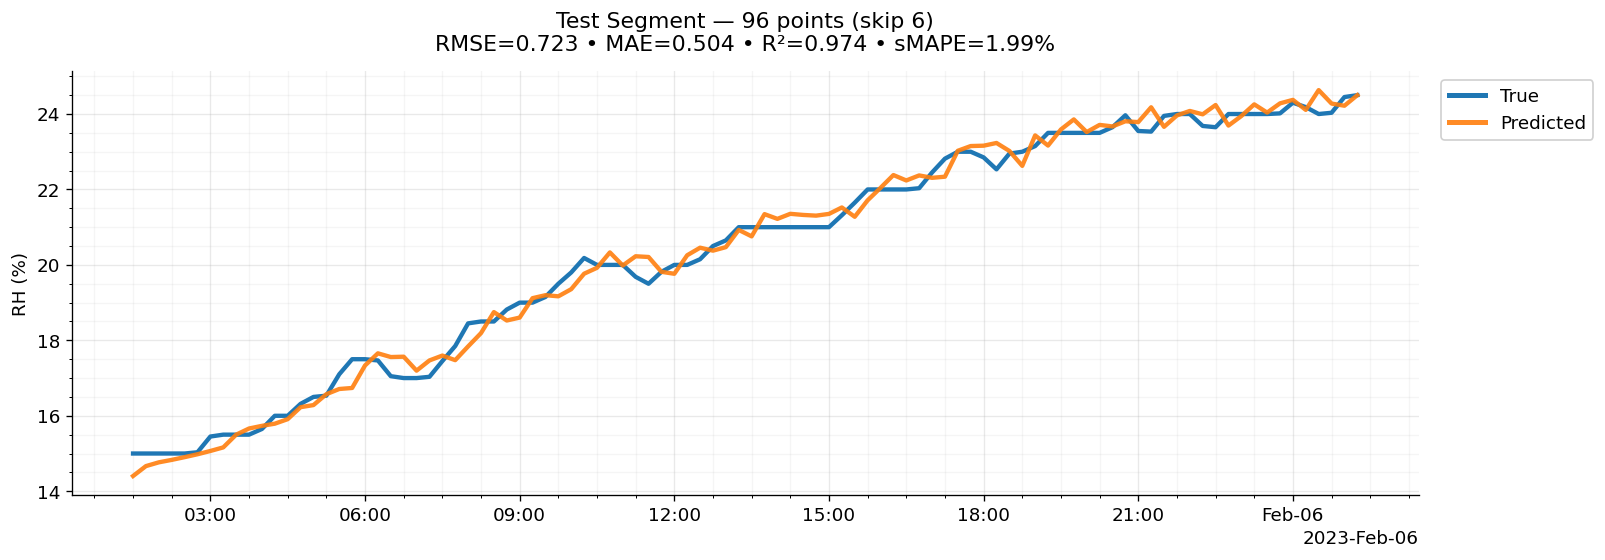

======= House 4 =========
Scaling columns: ['Tout', 'hvac_mode']
[01] Train Loss: 582.2062 | Val Loss: 16.4382
[02] Train Loss: 180.6622 | Val Loss: 73.8998
[03] Train Loss: 123.2449 | Val Loss: 128.0606
[04] Train Loss: 117.0084 | Val Loss: 129.4206
[05] Train Loss: 64.8001 | Val Loss: 1.0478
[06] Train Loss: 27.3237 | Val Loss: 0.8510
[07] Train Loss: 14.0206 | Val Loss: 0.2686
[08] Train Loss: 7.6648 | Val Loss: 0.2416
[09] Train Loss: 4.5097 | Val Loss: 0.2154
[10] Train Loss: 2.9198 | Val Loss: 0.2888
[11] Train Loss: 2.0504 | Val Loss: 0.2291
[12] Train Loss: 1.5473 | Val Loss: 0.2924
[13] Train Loss: 1.2179 | Val Loss: 0.1759
[14] Train Loss: 1.0325 | Val Loss: 0.2948
[15] Train Loss: 0.8597 | Val Loss: 0.1936
[16] Train Loss: 0.7720 | Val Loss: 0.1740
[17] Train Loss: 0.6948 | Val Loss: 0.2348
[18] Train Loss: 0.6707 | Val Loss: 0.6480
[19] Train Loss: 0.6283 | Val Loss: 0.1683
[20] Train Loss: 0.5596 | Val Loss: 0.2383
[21] Train Loss: 0.5746 | Val Loss: 0.3586
[22] Train Loss

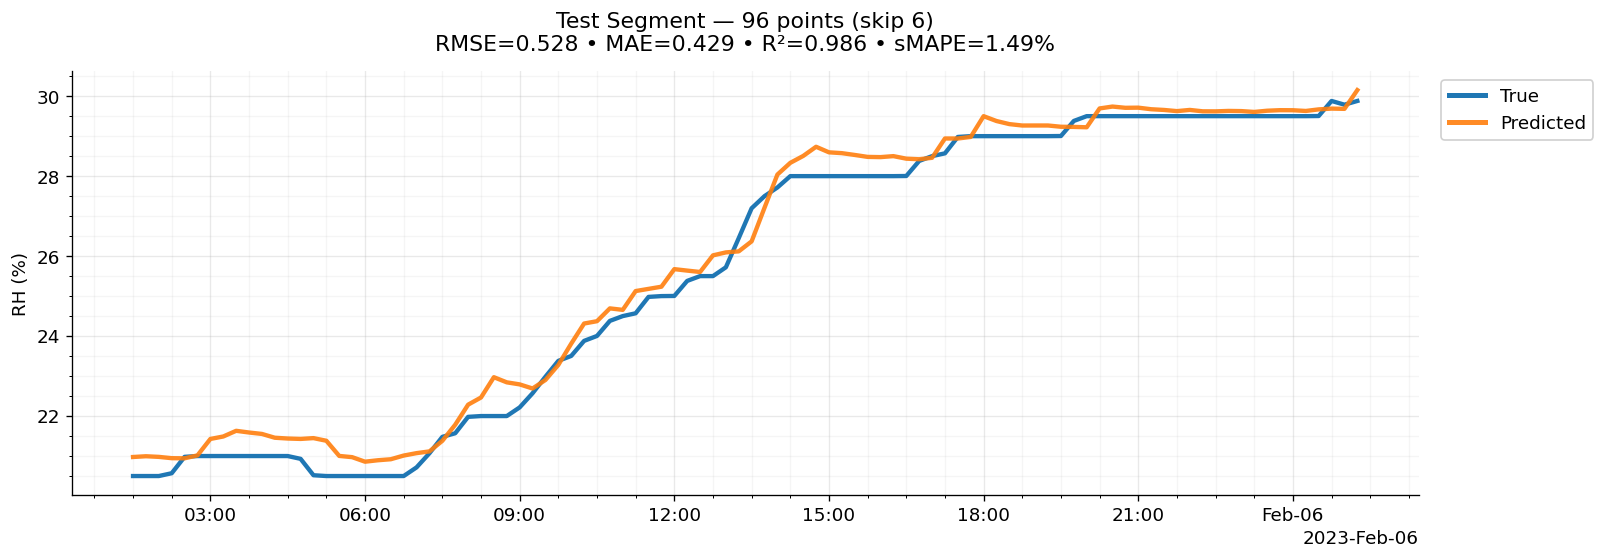

======= House 5 =========
Scaling columns: ['Tout', 'hvac_mode']
[01] Train Loss: 504.1316 | Val Loss: 34.9352
[02] Train Loss: 153.9404 | Val Loss: 61.6849
[03] Train Loss: 111.4463 | Val Loss: 94.1345
[04] Train Loss: 109.1908 | Val Loss: 100.5783
[05] Train Loss: 109.0215 | Val Loss: 102.2036
[06] Train Loss: 91.4259 | Val Loss: 1.1223
[07] Train Loss: 32.6428 | Val Loss: 2.2663
[08] Train Loss: 16.0040 | Val Loss: 1.0715
[09] Train Loss: 9.6450 | Val Loss: 0.6298
[10] Train Loss: 6.4240 | Val Loss: 0.7045
[11] Train Loss: 4.4521 | Val Loss: 0.6410
[12] Train Loss: 3.2022 | Val Loss: 0.6787
[13] Train Loss: 2.4044 | Val Loss: 0.5661
[14] Train Loss: 1.8629 | Val Loss: 0.5768
[15] Train Loss: 1.4373 | Val Loss: 0.5844
[16] Train Loss: 1.2102 | Val Loss: 0.5027
[17] Train Loss: 1.0142 | Val Loss: 0.6562
[18] Train Loss: 0.8905 | Val Loss: 0.6404
[19] Train Loss: 0.8016 | Val Loss: 0.4615
[20] Train Loss: 0.6685 | Val Loss: 0.5241
[21] Train Loss: 0.6470 | Val Loss: 0.4895
[22] Train L

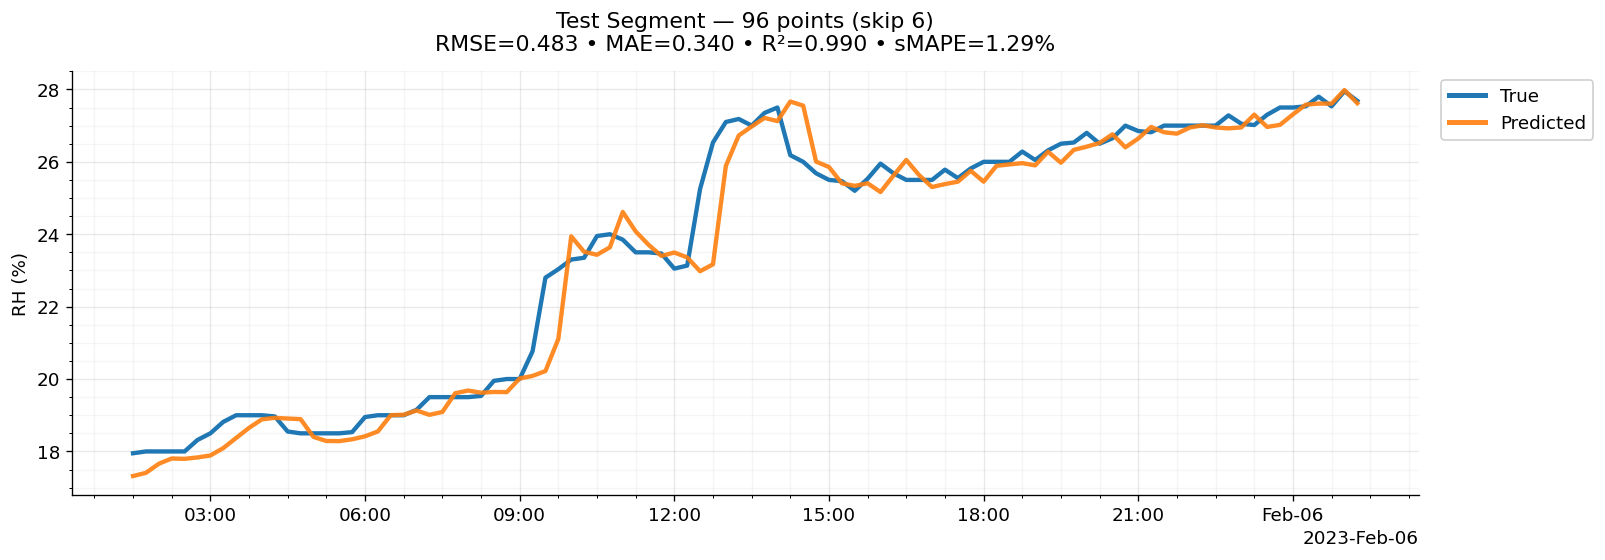

======= House 6 =========
Scaling columns: ['Tout', 'hvac_mode']
[01] Train Loss: 606.0770 | Val Loss: 32.8487
[02] Train Loss: 215.1836 | Val Loss: 72.8320
[03] Train Loss: 159.5861 | Val Loss: 119.9232
[04] Train Loss: 125.6785 | Val Loss: 1.7525
[05] Train Loss: 55.0489 | Val Loss: 1.3087
[06] Train Loss: 31.1819 | Val Loss: 1.0170
[07] Train Loss: 19.6962 | Val Loss: 0.8698
[08] Train Loss: 13.1790 | Val Loss: 1.1265
[09] Train Loss: 9.4202 | Val Loss: 1.1628
[10] Train Loss: 7.0114 | Val Loss: 0.7538
[11] Train Loss: 5.5043 | Val Loss: 0.7609
[12] Train Loss: 4.3636 | Val Loss: 0.7489
[13] Train Loss: 3.6675 | Val Loss: 0.7446
[14] Train Loss: 2.9945 | Val Loss: 0.7121
[15] Train Loss: 2.7507 | Val Loss: 0.7209
[16] Train Loss: 2.3829 | Val Loss: 0.7896
[17] Train Loss: 2.0398 | Val Loss: 0.6349
[18] Train Loss: 1.8487 | Val Loss: 1.0925
[19] Train Loss: 1.7410 | Val Loss: 0.6053
[20] Train Loss: 1.6601 | Val Loss: 0.5629
[21] Train Loss: 1.4635 | Val Loss: 0.5688
[22] Train Loss:

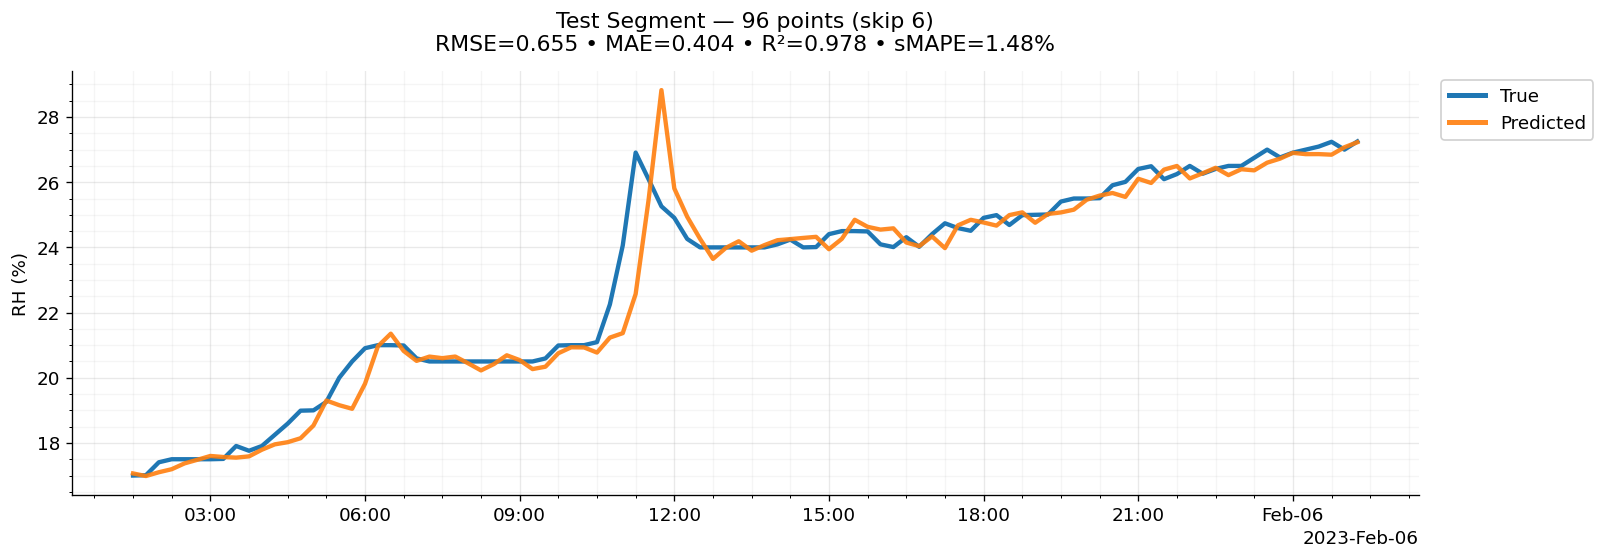

======= House 7 =========
Scaling columns: ['Tout', 'hvac_mode']
[01] Train Loss: 566.4182 | Val Loss: 41.3240
[02] Train Loss: 182.3115 | Val Loss: 39.1601
[03] Train Loss: 128.8970 | Val Loss: 70.0369
[04] Train Loss: 110.2275 | Val Loss: 2.0683
[05] Train Loss: 44.4967 | Val Loss: 1.7242
[06] Train Loss: 22.7216 | Val Loss: 1.3413
[07] Train Loss: 13.5591 | Val Loss: 1.1833
[08] Train Loss: 9.1138 | Val Loss: 1.3011
[09] Train Loss: 6.6275 | Val Loss: 1.2523
[10] Train Loss: 5.0996 | Val Loss: 0.8611
[11] Train Loss: 3.9798 | Val Loss: 0.9409
[12] Train Loss: 3.3637 | Val Loss: 0.8502
[13] Train Loss: 2.6971 | Val Loss: 0.8986
[14] Train Loss: 2.3220 | Val Loss: 1.5603
[15] Train Loss: 2.0673 | Val Loss: 1.5306
[16] Train Loss: 1.7705 | Val Loss: 0.7969
[17] Train Loss: 1.5524 | Val Loss: 0.8363
[18] Train Loss: 1.4209 | Val Loss: 0.7672
[19] Train Loss: 1.3397 | Val Loss: 0.7515
[20] Train Loss: 1.2376 | Val Loss: 0.8130
[21] Train Loss: 1.1976 | Val Loss: 1.1237
[22] Train Loss: 1

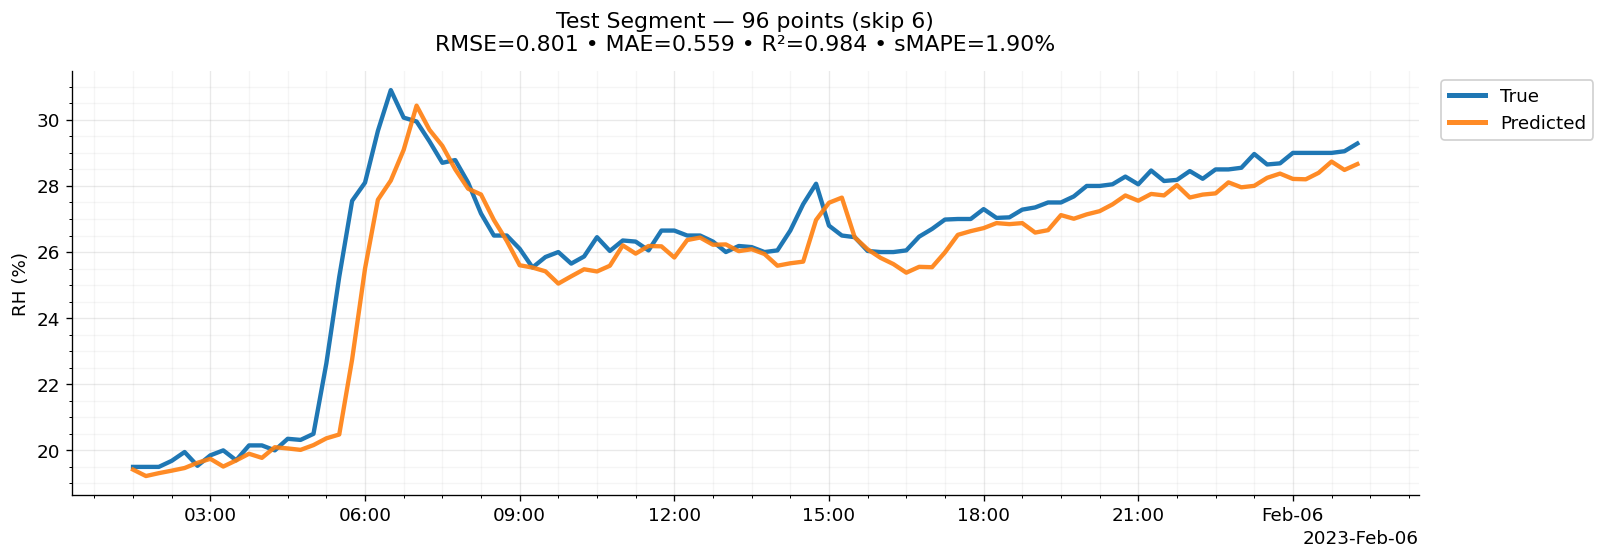

In [8]:
run_rh_cnnlstm_for_folder('datasets/retrofit/resampled', 'hvac_mode', 'models')